In [31]:
import numpy as np 
import matplotlib.pyplot as plt


In [32]:
conns_diff = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion_20_percent.npy")
conns_prop = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion_10_percent.npy")
# conns_prop = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_20_percent.npy")

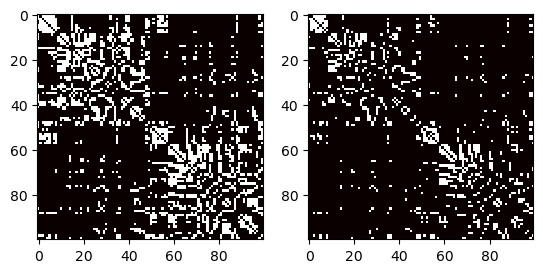

In [33]:
plt.subplot(1,2,1)
plt.imshow(conns_diff[0,:,:], cmap='hot', interpolation='nearest')
plt.subplot(1,2,2)
plt.imshow(conns_prop[0,:,:], cmap='hot', interpolation='nearest')

In [34]:
# from portrait_divergence import calculate_portrait_divergence
import networkx as nx

In [35]:
from src.comparing_connectomes.portrait_divergence_comparer import PortraitDivergence
import torch

In [36]:
portrait_div_comparer = PortraitDivergence()
for i in range(5):
    val = portrait_div_comparer(
        torch.Tensor(conns_diff[0,:,:]).unsqueeze(0), 
        torch.Tensor(conns_prop[i,:,:]).unsqueeze(0)
    )
    print(f"Subject {i} portrait divergence: {val}")


Subject 0 portrait divergence: {0: np.float64(0.7712963018487355)}
Subject 1 portrait divergence: {0: np.float64(0.7712963018487355)}
Subject 2 portrait divergence: {0: np.float64(0.7712963018487355)}
Subject 3 portrait divergence: {0: np.float64(0.7712963018487355)}
Subject 4 portrait divergence: {0: np.float64(0.7712963018487355)}


In [37]:
import pandas as pd 
import seaborn as sns

In [39]:
df = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/kaysons_generated_networks_diffusion/05_second_big_overnight_run_10201/summary_indiv_portrait_for_exp_05_second_big_overnight_run_10201.csv")
df.head()

,network_index,filename,eta,gamma,id,PortraitDiv_subject_0
0,0,net_eta2.77999997138977_gamma0.416999995708465...,2.78,0.417,0,0.959531
1,1,net_eta1.899999976158142_gamma0.46099999547004...,1.90,0.461,0,0.959531
2,2,net_eta2.009999990463256_gamma-0.0230000019073...,2.01,-0.023,0,0.959531
3,3,net_eta2.450000047683716_gamma-0.0560000017285...,2.45,-0.056,0,0.959531
4,4,net_eta2.230000019073486_gamma-0.0890000015497...,2.23,-0.089,0,0.959531


<Axes: xlabel='eta', ylabel='gamma'>

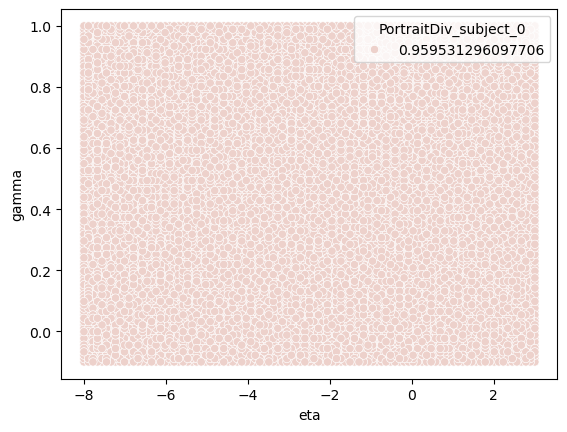

In [40]:
sns.scatterplot(data=df, x='eta', y='gamma', hue="PortraitDiv_subject_0")